# 02. 성능 결과 & 오류 분석

- 최종 구성 : 피처 `dQ_log_var` 1개 · target log10 · 후보 5개 중 1-SE 규칙으로 Ridge 선택 (`python src/train.py mine log`)
- 각 섹션 : 수치·그래프 → 끝에 `해석 / 시사점` 정리

In [1]:
import sys; sys.path.insert(0, '../src')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

RES, FIG = Path('../results'), Path('../results/figures')
pd.set_option('display.width', 200)
def save(fig, name): fig.savefig(FIG / f'{name}.png', dpi=120, bbox_inches='tight')

feats = pd.read_csv('../data/processed/features.csv')
pred = pd.read_csv(RES / 'predictions_mine_log.csv').merge(
    feats[['cell_id', 'dQ_log_var', 'chargetime_2_6']], on='cell_id')
pred['signed_%'] = (pred.pred - pred.true) / pred.true * 100
pred['b2_group'] = np.where(pred.batch != 'b2', '', np.where(pred.chargetime_2_6 < 10.1, 'b2 fast(~10.04min)', 'b2 slow(~10.17min)'))
b1_used = feats[(feats.batch == 'b1') & ~feats.censored]

## 1. 성능표 (포맷)

In [2]:
pd.read_csv(RES / 'model_performance_mine_log.csv')

,구분,MAPE (%),비고
0,Train (Batch 1 CV),8.86,NaN
1,Valid (Batch 1 Hold-out),8.84,NaN
2,Test (Batch 2),29.08,NaN
3,Gap (Train-Valid),-0.03,(+) : 과적합 의심
4,Gap (Valid-Test),20.25,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),19.98,Target : 원논문 9.1%
6,Test (Batch 3),12.61,NaN
7,Gap (Batch2-Batch3),-16.48,Test 성능 간 비교
8,"Gap (Target-Test, Batch 3)",3.51,"Batch 3 기준, 원논문 성능 비교"


In [3]:
# 피처 구성별 비교 (모두 log target, 1-SE 선택 모델)
import train as T
rows = []
for fs in ['mine', 'discharge', 'full']:
    comp = pd.read_csv(RES / f'model_comparison_{fs}_log.csv')
    b = T.select_1se(comp)
    rows.append({'feature_set': fs, 'n_features': len(T.FEATURE_SETS[fs]), 'model': b.model,
                 'train_cv': b.train_cv, 'valid': b.valid, 'test_b2': b.test_b2, 'test_b3': b.test_b3})
pd.DataFrame(rows).round(2)

,feature_set,n_features,model,train_cv,valid,test_b2,test_b3
0,mine,1,Ridge,8.86,8.84,29.08,12.61
1,discharge,6,ElasticNet,7.60,7.67,41.50,11.32
2,full,9,Ridge,6.27,6.87,44.16,13.88


In [4]:
# 후보 모델 전체 (mine, log)
pd.read_csv(RES / 'model_comparison_mine_log.csv').round(2)

,model,best_params,train_cv,cv_se,valid,test_b2,test_b3
0,Ridge,{'alpha': 1.0},8.86,0.72,8.84,29.08,12.61
1,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.1}",8.87,0.71,8.73,29.01,12.63
2,SVR,"{'C': 10, 'epsilon': 0.01}",8.60,1.89,15.34,32.83,16.11
3,RandomForest,"{'max_depth': 2, 'n_estimators': 300}",10.06,1.35,9.31,29.28,15.69
4,GBR,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",9.76,1.12,8.18,30.77,15.07


> **해석 / 시사점**
>
> - B1 안에서는 과적합 없음 (Gap(Train-Valid) -0.03), 원논문 9.1% 수준 재현
> - 피처를 늘리면 B1은 좋아지지만(7.60 / 6.27) B2는 나빠짐(41.50 / 44.16) → 추가 피처는 B1에서만 통하는 관계
> - CV 최저는 SVR(8.60%)이나, 1-SE 기준(≤ 10.49%) 안에서 가장 단순한 Ridge(8.86%) 선택

## 2. 예측 vs 실제

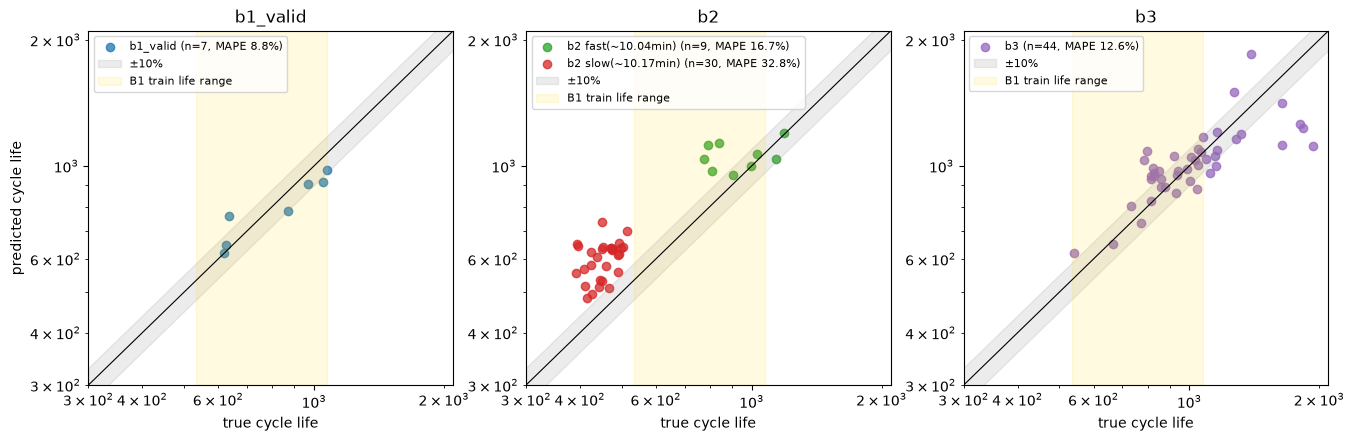

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
groups = [('b1_valid', [('b1_valid', 'tab:blue')]),
          ('b2', [('b2 fast(~10.04min)', 'tab:green'), ('b2 slow(~10.17min)', 'tab:red')]),
          ('b3', [('b3', 'tab:purple')])]
for ax, (b, sub) in zip(axes, groups):
    for label, c in sub:
        d = pred[(pred.batch == b) & ((pred.b2_group == label) if b == 'b2' else True)]
        ax.scatter(d.true, d.pred, color=c, alpha=.75, label=f'{label} (n={len(d)}, MAPE {d.ape.mean():.1f}%)')
    lim = [300, 2100]
    ax.plot(lim, lim, 'k-', lw=.8); ax.fill_between(lim, [l * .9 for l in lim], [l * 1.1 for l in lim], color='gray', alpha=.15, label='±10%')
    ax.axvspan(b1_used.cycle_life.min(), b1_used.cycle_life.max(), color='gold', alpha=.12, label='B1 train life range')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('true cycle life'); ax.set_title(b); ax.legend(fontsize=8)
axes[0].set_ylabel('predicted cycle life')
save(fig, '7_parity')

In [6]:
# 예측 편향 : (+) = 실제보다 길게 예측
pred.groupby(['batch', 'b2_group'])['signed_%'].describe()[['count', 'mean', '50%', 'min', 'max']].round(1)

count  mean   50%   min   max
batch    b2_group                                         
b1_valid                       7.0  -2.1  -6.2 -12.9  19.6
b2       b2 fast(~10.04min)    9.0  14.7   5.5  -8.8  41.6
         b2 slow(~10.17min)   30.0  32.8  32.9   9.8  65.7
b3                            44.0   0.8   1.5 -42.2  36.2

In [7]:
# 실제 수명 구간별 오차 방향
pred['life_bin'] = pd.cut(pred.true, [0, 500, 800, 1100, 2500], labels=['<500', '500-800', '800-1100', '>1100'])
pred.groupby(['batch', 'life_bin'], observed=True)['signed_%'].agg(['count', 'mean']).round(1)

count  mean
batch    life_bin             
b1_valid 500-800       3   7.8
         800-1100      4  -9.6
b2       <500         28  32.9
         500-800       4  34.9
         800-1100      5  13.0
         >1100         2  -3.8
b3       500-800       6  13.9
         800-1100     24   4.5
         >1100        14 -11.0

> **해석 / 시사점**
>
> - B2 10.17분 그룹 30셀은 전부 실제보다 길게 예측(평균 +32.8%), 10.04분 그룹은 +14.7%
> - B3는 전체 편향은 거의 없지만(+0.8%) 수명 1,100 이상 셀은 평균 -11% 과소 예측 → 학습 범위(최대 1,074) 위쪽 외삽

## 3. 학습 범위 밖 입력 (외삽 여부)

- B1 학습 셀의 `dQ_log_var` · 수명 범위를 벗어난 테스트 셀 비율

In [8]:
lo, hi = b1_used.dQ_log_var.min(), b1_used.dQ_log_var.max()
llo, lhi = b1_used.cycle_life.min(), b1_used.cycle_life.max()
print(f'B1 dQ_log_var range : {lo:.3f} ~ {hi:.3f},  life range : {llo:.0f} ~ {lhi:.0f}')
t = pred[pred.batch.isin(['b2', 'b3'])].assign(
    x_out=lambda d: ~d.dQ_log_var.between(lo, hi), y_out=lambda d: ~d.true.between(llo, lhi))
t.groupby('batch').agg(n=('cell_id', 'size'), feature_out_pct=('x_out', 'mean'), life_out_pct=('y_out', 'mean'),
                       mape_in=('ape', lambda s: s[~t.loc[s.index, 'y_out']].mean()),
                       mape_out=('ape', lambda s: s[t.loc[s.index, 'y_out']].mean())).round(3)

B1 dQ_log_var range : -4.179 ~ -3.350,  life range : 534 ~ 1074


,n,feature_out_pct,life_out_pct,mape_in,mape_out
batch,,,,,
b2,39,0.436,0.821,20.023,31.067
b3,44,0.477,0.364,9.838,17.450


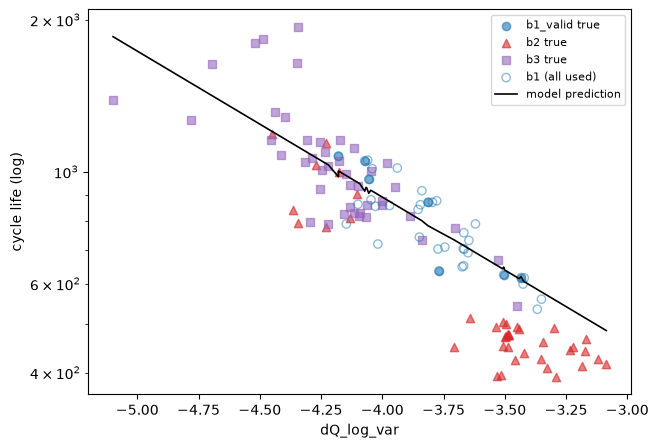

In [9]:
# 피처-수명 관계 : B1에서 학습한 직선이 B2/B3에도 맞는가
fig, ax = plt.subplots(figsize=(7, 5))
for b, m, c in [('b1_valid', 'o', 'tab:blue'), ('b2', '^', 'tab:red'), ('b3', 's', 'tab:purple')]:
    d = pred[pred.batch == b]; ax.scatter(d.dQ_log_var, d.true, marker=m, color=c, alpha=.6, label=f'{b} true')
ax.scatter(b1_used.dQ_log_var, b1_used.cycle_life, marker='o', facecolors='none', edgecolors='tab:blue', alpha=.5, label='b1 (all used)')
xs = pred.sort_values('dQ_log_var')
ax.plot(xs.dQ_log_var, xs.pred, 'k-', lw=1.2, label='model prediction')
ax.set_yscale('log'); ax.set_xlabel('dQ_log_var'); ax.set_ylabel('cycle life (log)'); ax.legend(fontsize=8)
save(fig, '7_feature_fit')

In [10]:
# 운영 시에는 실제 수명을 모르므로, 입력(dQ_log_var) 기준으로 범위 안/밖 비교
t['dq_out'] = ~t.dQ_log_var.between(lo, hi)
t.groupby(['batch', 'dq_out']).ape.agg(['count', 'mean']).round(1)

count  mean
batch dq_out             
b2    False      22  34.9
      True       17  21.6
b3    False      23   9.1
      True       21  16.4

> **해석 / 시사점**
>
> - 수명 기준으로 B2 셀 82%가 학습 범위 밖 → 외삽
> - ΔQ 기준으로 나누면 B2는 범위 안 셀이 오히려 더 틀림(34.9% vs 21.6%) → 같은 ΔQ인데 수명이 더 짧은 '관계 변화'가 핵심 (그림에서 B2 점이 모델 선 아래)
> - B3는 ΔQ 범위 밖 셀이 더 틀림(16.4% vs 9.1%) → 외삽형 오차라 범위 밖 경고로 구분 가능

## 4. 가장 크게 틀린 셀

In [11]:
pred.sort_values('ape', ascending=False).head(12)[
    ['batch', 'cell_id', 'policy', 'b2_group', 'true', 'pred', 'signed_%', 'dQ_log_var']].round(1)

,batch,cell_id,policy,b2_group,true,pred,signed_%,dQ_log_var
13,b2,b2c6,3.6C(9%)-5C,b2 slow(~10.17min),393.0,651.3,65.7,-3.5
25,b2,b2c18,5.2C(50%)-4.25C,b2 slow(~10.17min),449.0,732.9,63.2,-3.7
22,b2,b2c15,3.6C(9%)-5C,b2 slow(~10.17min),396.0,645.4,63.0,-3.5
9,b2,b2c2,5.2C(50%)-4.25C,b2 slow(~10.17min),424.0,621.8,46.6,-3.5
82,b3,b3c38,5C(67%)-4C,,1935.0,1118.5,-42.2,-4.3
34,b2,b2c29,5.2C(58%)-4C,b2 slow(~10.17min),452.0,641.9,42.0,-3.5
26,b2,b2c19,6C(60%)-3C,b2 slow(~10.17min),392.0,555.8,41.8,-3.3
16,b2,b2c9,5.6C(26%)-4.5C,b2 fast(~10.04min),791.0,1120.3,41.6,-4.3
18,b2,b2c11,5.2C(50%)-4.25C,b2 slow(~10.17min),449.0,632.2,40.8,-3.5
28,b2,b2c21,6C(60%)-3C,b2 slow(~10.17min),408.0,568.8,39.4,-3.3


In [12]:
# B2 숨은 그룹별 성능
pred[pred.batch == 'b2'].groupby('b2_group').agg(n=('cell_id', 'size'), mape=('ape', 'mean'),
                                                 bias=('signed_%', 'mean'), life_med=('true', 'median')).round(1)

,n,mape,bias,life_med
b2_group,,,,
b2 fast(~10.04min),9,16.7,14.7,904.0
b2 slow(~10.17min),30,32.8,32.8,451.0


> **해석 / 시사점**
>
> - 오차 상위 12개 중 11개가 B2, 그중 10개가 10.17분 그룹
> - 그룹별 MAPE 32.8%(10.17분) vs 16.7%(10.04분) → B2 오차의 대부분이 10.17분 그룹에서 발생

## 5. 오류 분석 / 도메인 해석 정리

- 모델이 가장 크게 틀린 셀의 공통점 : B2 10.17분 그룹(단수명) — 30셀 전부 실제보다 길게 예측 (+9.8 ~ +65.7%)
- 원인 가설 : ① B2 수명이 학습 범위(534~1,074) 밖 → 외삽 ② 같은 ΔQ에서도 B2 셀이 더 일찍 수명 종료 → B1 규칙이 B2에서 어긋남
- 개선 방향 : ΔQ가 학습 범위 밖이면 경고(B3형 외삽 구분) + 범위 경고로 못 잡는 관계 변화(B2형)는 새 배치 셀 몇 개의 실제 수명으로 재보정
- BESS 활용 : 교체 시점 조기 계획 — 초기 100 사이클 시점에 수명 추정 → 교체 예산·일정 수립 (조건이 가까우면 오차 약 9~13%)
- 한계 : 데이터는 30°C 항온 챔버의 4C 완전방전 셀 → 부분 충방전·온도 변동이 있는 실운영에서는 같은 ΔQ를 얻기 어려움 → 기준 진단 사이클 또는 실운영 데이터 재학습 필요